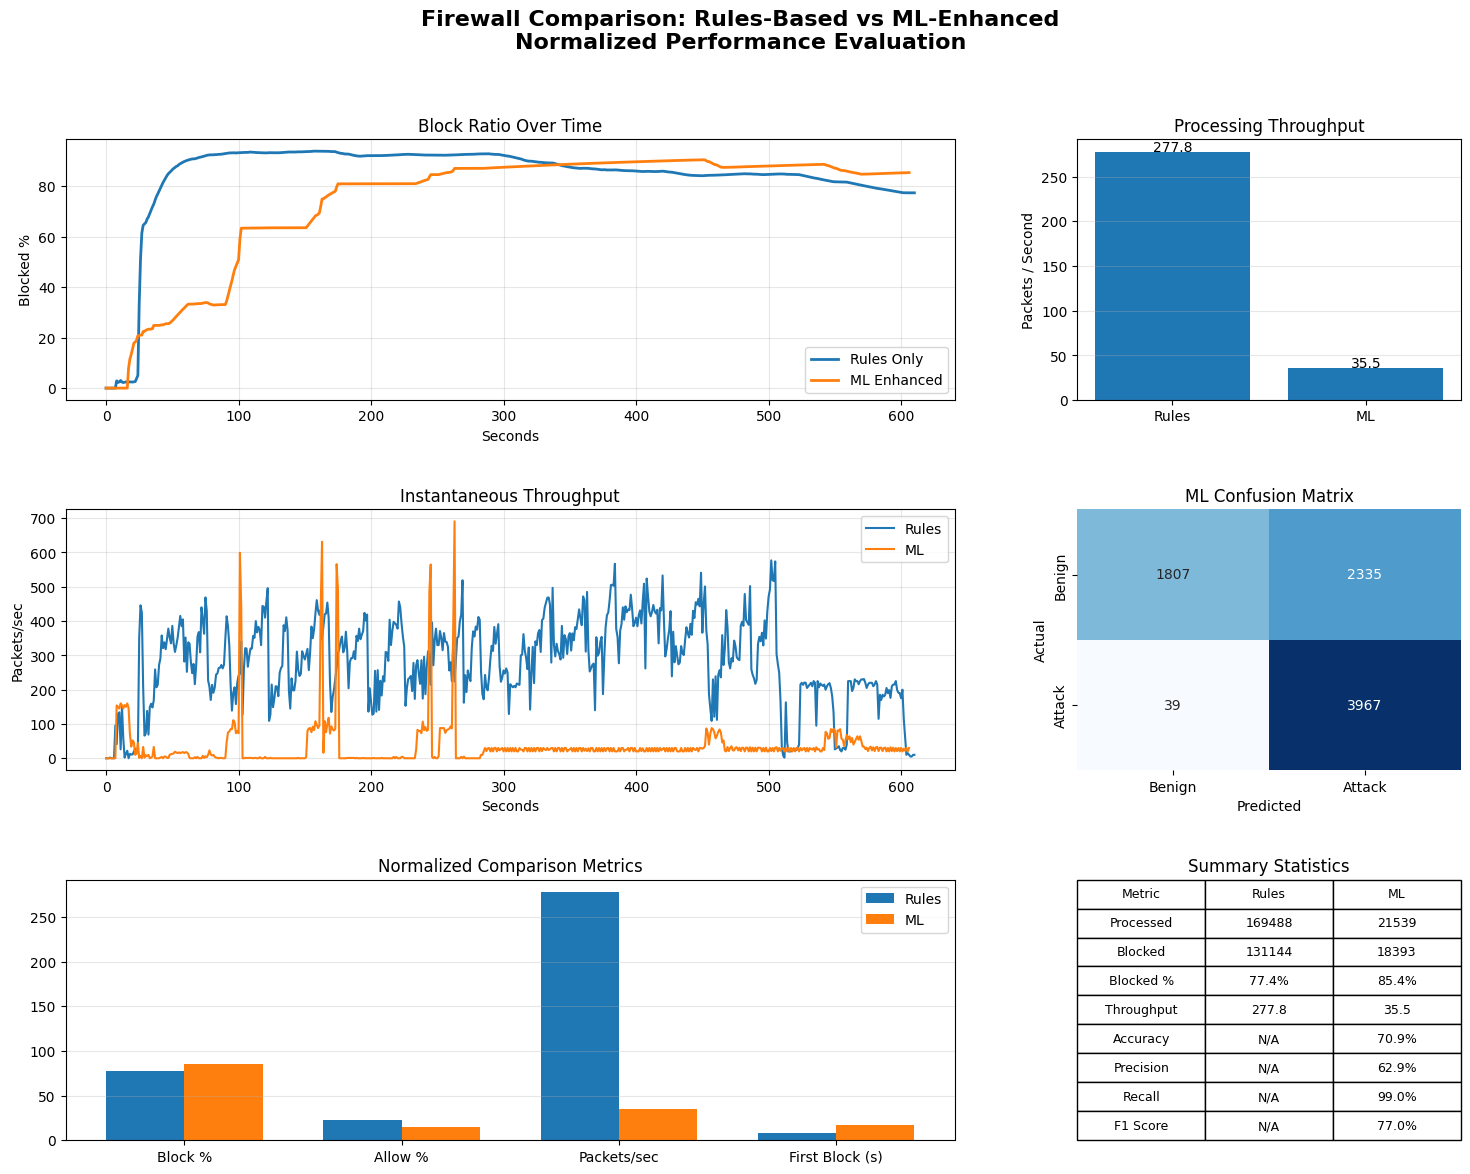

[+] Saved firewall_comparison_corrected.png


In [1]:
# compare_experiments.py
# Fair comparison of Rules-Only vs ML-Enhanced Firewall
# Uses normalized metrics instead of misleading raw totals

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns

# ==========================================================
# LOAD FILES
# ==========================================================

rules_log = pd.read_csv("experiment_rules_only.csv")
ml_log    = pd.read_csv("experiment_ml_enabled.csv")

# ML prediction logs
dfs = []
for file in ["ml_results_0.csv", "ml_results_1.csv"]:
    try:
        dfs.append(pd.read_csv(file))
    except FileNotFoundError:
        pass

ml_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def processed_packets(df):
    return df["packets_allowed"] + df["packets_blocked_total"]

def safe_div(a, b):
    return a / b if b != 0 else 0

def cumulative_ratio(num, denom):
    out = []
    for n, d in zip(num, denom):
        out.append(n / d if d > 0 else 0)
    return np.array(out)

# ==========================================================
# FINAL VALUES
# ==========================================================

rules_time = rules_log["elapsed_seconds"].iloc[-1]
ml_time    = ml_log["elapsed_seconds"].iloc[-1]

rules_processed = processed_packets(rules_log)
ml_processed    = processed_packets(ml_log)

rules_total_processed = rules_processed.iloc[-1]
ml_total_processed    = ml_processed.iloc[-1]

rules_total_blocked = rules_log["packets_blocked_total"].iloc[-1]
ml_total_blocked    = ml_log["packets_blocked_total"].iloc[-1]

rules_total_allowed = rules_log["packets_allowed"].iloc[-1]
ml_total_allowed    = ml_log["packets_allowed"].iloc[-1]

# ==========================================================
# NORMALIZED METRICS
# ==========================================================

rules_pps = safe_div(rules_total_processed, rules_time)
ml_pps    = safe_div(ml_total_processed, ml_time)

rules_block_ratio = safe_div(rules_total_blocked, rules_total_processed)
ml_block_ratio    = safe_div(ml_total_blocked, ml_total_processed)

rules_allow_ratio = safe_div(rules_total_allowed, rules_total_processed)
ml_allow_ratio    = safe_div(ml_total_allowed, ml_total_processed)

# time to first block
try:
    rules_first_block = rules_log[
        rules_log["packets_blocked_total"] > 0
    ]["elapsed_seconds"].iloc[0]
except:
    rules_first_block = np.nan

try:
    ml_first_block = ml_log[
        ml_log["packets_blocked_total"] > 0
    ]["elapsed_seconds"].iloc[0]
except:
    ml_first_block = np.nan

# ==========================================================
# ML CLASSIFICATION METRICS
# ==========================================================

acc = prec = rec = f1 = 0
cm = None

if not ml_df.empty and ml_df["y_true"].nunique() > 1:
    y_true = ml_df["y_true"]
    y_pred = ml_df["y_pred"]

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

# ==========================================================
# FIGURE SETUP
# ==========================================================

fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    "Firewall Comparison: Rules-Based vs ML-Enhanced\n"
    "Normalized Performance Evaluation",
    fontsize=16,
    fontweight="bold"
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

# ==========================================================
# PANEL 1 — Block Ratio Over Time
# ==========================================================

ax1 = fig.add_subplot(gs[0, :2])

rules_ratio_time = cumulative_ratio(
    rules_log["packets_blocked_total"],
    processed_packets(rules_log)
)

ml_ratio_time = cumulative_ratio(
    ml_log["packets_blocked_total"],
    processed_packets(ml_log)
)

ax1.plot(
    rules_log["elapsed_seconds"],
    rules_ratio_time * 100,
    label="Rules Only",
    linewidth=2
)

ax1.plot(
    ml_log["elapsed_seconds"],
    ml_ratio_time * 100,
    label="ML Enhanced",
    linewidth=2
)

ax1.set_title("Block Ratio Over Time")
ax1.set_xlabel("Seconds")
ax1.set_ylabel("Blocked %")
ax1.legend()
ax1.grid(alpha=0.3)

# ==========================================================
# PANEL 2 — Throughput
# ==========================================================

ax2 = fig.add_subplot(gs[0, 2])

labels = ["Rules", "ML"]
vals   = [rules_pps, ml_pps]

bars = ax2.bar(labels, vals)

for b in bars:
    ax2.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 1,
        f"{b.get_height():.1f}",
        ha="center"
    )

ax2.set_title("Processing Throughput")
ax2.set_ylabel("Packets / Second")
ax2.grid(axis="y", alpha=0.3)

# ==========================================================
# PANEL 3 — Packets Processed Per Second
# ==========================================================

ax3 = fig.add_subplot(gs[1, :2])

rules_rate = processed_packets(rules_log).diff().fillna(0)
ml_rate    = processed_packets(ml_log).diff().fillna(0)

ax3.plot(rules_log["elapsed_seconds"], rules_rate, label="Rules")
ax3.plot(ml_log["elapsed_seconds"], ml_rate, label="ML")

ax3.set_title("Instantaneous Throughput")
ax3.set_xlabel("Seconds")
ax3.set_ylabel("Packets/sec")
ax3.legend()
ax3.grid(alpha=0.3)

# ==========================================================
# PANEL 4 — Confusion Matrix
# ==========================================================

ax4 = fig.add_subplot(gs[1, 2])

if cm is not None:
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Attack"],
        yticklabels=["Benign", "Attack"],
        ax=ax4
    )
    ax4.set_title("ML Confusion Matrix")
    ax4.set_xlabel("Predicted")
    ax4.set_ylabel("Actual")
else:
    ax4.text(
        0.5, 0.5,
        "No ML Labels Available",
        ha="center",
        va="center"
    )
    ax4.set_title("Confusion Matrix")

# ==========================================================
# PANEL 5 — Key Metrics
# ==========================================================

ax5 = fig.add_subplot(gs[2, :2])

metric_names = [
    "Block %",
    "Allow %",
    "Packets/sec",
    "First Block (s)"
]

rules_vals = [
    rules_block_ratio * 100,
    rules_allow_ratio * 100,
    rules_pps,
    rules_first_block
]

ml_vals = [
    ml_block_ratio * 100,
    ml_allow_ratio * 100,
    ml_pps,
    ml_first_block
]

x = np.arange(len(metric_names))
w = 0.36

bars1 = ax5.bar(x - w/2, rules_vals, w, label="Rules")
bars2 = ax5.bar(x + w/2, ml_vals, w, label="ML")

ax5.set_xticks(x)
ax5.set_xticklabels(metric_names)
ax5.set_title("Normalized Comparison Metrics")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)

# ==========================================================
# PANEL 6 — Summary Table
# ==========================================================

ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")

table_data = [
    ["Metric", "Rules", "ML"],
    ["Processed", int(rules_total_processed), int(ml_total_processed)],
    ["Blocked", int(rules_total_blocked), int(ml_total_blocked)],
    ["Blocked %", f"{rules_block_ratio:.1%}", f"{ml_block_ratio:.1%}"],
    ["Throughput", f"{rules_pps:.1f}", f"{ml_pps:.1f}"],
    ["Accuracy", "N/A", f"{acc:.1%}"],
    ["Precision", "N/A", f"{prec:.1%}"],
    ["Recall", "N/A", f"{rec:.1%}"],
    ["F1 Score", "N/A", f"{f1:.1%}"],
]

table = ax6.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(9)

ax6.set_title("Summary Statistics")

# ==========================================================
# SAVE
# ==========================================================

plt.savefig("firewall_comparison_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

print("[+] Saved firewall_comparison_corrected.png")

In [1]:
# compare_experiments.py
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# ------------------ LOAD DATA ------------------

rules_log = pd.read_csv("experiment_rules_only.csv")
ml_log    = pd.read_csv("experiment_ml_enabled.csv")

rules_ml  = pd.read_csv("ml_results_0.csv")   # normal traffic results
            # (these only exist for ml_enabled run)

# Load attack traffic results
try:
    attack_ml = pd.read_csv("ml_results_1.csv")
    ml_df = pd.concat([rules_ml, attack_ml], ignore_index=True)
except FileNotFoundError:
    ml_df = rules_ml


In [3]:
# ------------------ FIGURE SETUP ------------------

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "ML-Enhanced Firewall vs Rule-Based Firewall\nPerformance Comparison",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)


<Figure size 1600x1200 with 0 Axes>

In [ ]:
# ------------------ PANEL 1: Packets Blocked Over Time ------------------

ax1 = fig.add_subplot(gs[0, :2])

ax1.plot(rules_log["elapsed_seconds"],
         rules_log["packets_blocked_total"],
         label="Rules Only", color="#e05c5c", linewidth=2)
ax1.plot(ml_log["elapsed_seconds"],
         ml_log["packets_blocked_total"],
         label="ML Enhanced", color="#5c8de0", linewidth=2)

ax1.set_title("Cumulative Packets Blocked Over Time")
ax1.set_xlabel("Elapsed Seconds")
ax1.set_ylabel("Packets Blocked")
ax1.legend()
ax1.grid(True, alpha=0.3)


In [5]:
# ------------------ PANEL 2: ML vs Rule Block Breakdown (bar) ------------------

ax2 = fig.add_subplot(gs[0, 2])

categories  = ["ML\nBlocks", "Rule\nBlocks", "Total\nBlocked", "Allowed"]
rules_vals  = [
    0,
    rules_log["rule_blocks"].iloc[-1],
    rules_log["packets_blocked_total"].iloc[-1],
    rules_log["packets_allowed"].iloc[-1]
]
ml_vals = [
    ml_log["ml_blocks"].iloc[-1],
    ml_log["rule_blocks"].iloc[-1],
    ml_log["packets_blocked_total"].iloc[-1],
    ml_log["packets_allowed"].iloc[-1]
]

x     = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, rules_vals, width, label="Rules Only",
        color="#e05c5c", alpha=0.85)
ax2.bar(x + width/2, ml_vals,    width, label="ML Enhanced",
        color="#5c8de0", alpha=0.85)

ax2.set_title("Total Event Counts")
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis="y")

In [6]:
# ------------------ PANEL 3: Packets Blocked Rate Over Time ------------------

ax3 = fig.add_subplot(gs[1, :2])

# Compute per-second block rate (diff of cumulative)
rules_rate = rules_log["packets_blocked_total"].diff().fillna(0)
ml_rate    = ml_log["packets_blocked_total"].diff().fillna(0)

ax3.fill_between(rules_log["elapsed_seconds"], rules_rate,
                 alpha=0.4, color="#e05c5c", label="Rules Only")
ax3.fill_between(ml_log["elapsed_seconds"],    ml_rate,
                 alpha=0.4, color="#5c8de0",   label="ML Enhanced")

ax3.set_title("Packets Blocked Per Second (Attack Detection Speed)")
ax3.set_xlabel("Elapsed Seconds")
ax3.set_ylabel("Blocks/sec")
ax3.legend()
ax3.grid(True, alpha=0.3)

In [7]:
# ------------------ PANEL 4: Confusion Matrix ------------------

ax4 = fig.add_subplot(gs[1, 2])

if len(ml_df) > 0 and ml_df["y_true"].nunique() > 1:
    cm = confusion_matrix(ml_df["y_true"], ml_df["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", ax=ax4,
        cmap="Blues",
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"],
        cbar=False
    )
    ax4.set_title("ML Model\nConfusion Matrix")
    ax4.set_xlabel("Predicted")
    ax4.set_ylabel("Actual")
else:
    ax4.text(0.5, 0.5, "Insufficient data\nfor confusion matrix",
             ha="center", va="center", transform=ax4.transAxes, color="gray")
    ax4.set_title("ML Confusion Matrix")

In [8]:
# ------------------ PANEL 5: Summary Metrics Bar Chart ------------------

ax5 = fig.add_subplot(gs[2, :2])

# Compute summary metrics
total_time    = rules_log["elapsed_seconds"].iloc[-1]
rules_block_rate = rules_log["packets_blocked_total"].iloc[-1] / total_time
ml_block_rate    = ml_log["packets_blocked_total"].iloc[-1]    / total_time

rules_allow_rate = rules_log["packets_allowed"].iloc[-1] / total_time
ml_allow_rate    = ml_log["packets_allowed"].iloc[-1]    / total_time

# Time to first block (when did blocking start?)
rules_first_block = rules_log[rules_log["packets_blocked_total"] > 0]["elapsed_seconds"].min()
ml_first_block    = ml_log[ml_log["ml_blocks"] > 0]["elapsed_seconds"].min()

metrics       = ["Block Rate\n(pkts/sec)", "Allow Rate\n(pkts/sec)",
                 "Time to\nFirst ML Block (s)"]
rules_metrics = [rules_block_rate, rules_allow_rate, rules_first_block or 999]
ml_metrics    = [ml_block_rate,    ml_allow_rate,    ml_first_block    or 999]

x     = np.arange(len(metrics))
width = 0.35

bars1 = ax5.bar(x - width/2, rules_metrics, width,
                label="Rules Only", color="#e05c5c", alpha=0.85)
bars2 = ax5.bar(x + width/2, ml_metrics,    width,
                label="ML Enhanced", color="#5c8de0", alpha=0.85)

ax5.set_title("Key Performance Metrics Comparison")
ax5.set_xticks(x)
ax5.set_xticklabels(metrics)
ax5.legend()
ax5.grid(True, alpha=0.3, axis="y")

# Value labels on bars
for bar in bars1:
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{bar.get_height():.1f}",
             ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{bar.get_height():.1f}",
             ha="center", va="bottom", fontsize=8)

In [13]:
# ------------------ PANEL 6: Summary Stats Table ------------------

ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")

# Build summary from ml_results if available
if len(ml_df) > 0 and ml_df["y_true"].nunique() > 1:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    acc  = accuracy_score(ml_df["y_true"],  ml_df["y_pred"])
    prec = precision_score(ml_df["y_true"], ml_df["y_pred"], zero_division=0)
    rec  = recall_score(ml_df["y_true"],    ml_df["y_pred"], zero_division=0)
    f1   = f1_score(ml_df["y_true"],        ml_df["y_pred"], zero_division=0)
else:
    acc = prec = rec = f1 = 0.0

table_data = [
    ["Metric",            "Rules Only", "ML Enhanced"],
    ["Total Blocked",
     str(int(rules_log["packets_blocked_total"].iloc[-1])),
     str(int(ml_log["packets_blocked_total"].iloc[-1]))],
    ["ML Blocks",         "0",
     str(int(ml_log["ml_blocks"].iloc[-1]))],
    ["ML Accuracy",       "N/A",        f"{acc:.1%}"],
    ["ML Precision",      "N/A",        f"{prec:.1%}"],
    ["ML Recall",         "N/A",        f"{rec:.1%}"],
    ["ML F1 Score",       "N/A",        f"{f1:.1%}"],
]

table = ax6.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Highlight header
for j in range(3):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Highlight ML column
for i in range(1, len(table_data)):
    table[i, 2].set_facecolor("#e8f0fe")

ax6.set_title("Summary Statistics", pad=10)

plt.show()

In [12]:
# ------------------ SAVE ------------------
plt.show()
plt.savefig("firewall_comparison.png", dpi=150, bbox_inches="tight")
print("[+] Saved firewall_comparison.png")

[+] Saved firewall_comparison.png


<Figure size 640x480 with 0 Axes>